In [1]:
import jax.numpy as jnp

import sys

sys.path.append("./siegel_analyses/scripts/")
sys.path.insert(1,'./ibl_analyses/scripts/')

import netrep_helpers as nh
import utils
import loader
import setup
import matplotlib.pyplot as plt

import seaborn as sns
%load_ext autoreload
%autoreload 2
import scipy.stats as sts
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

import imp
imp.reload(setup)
imp.reload(loader)
imp.reload(utils)
import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import psychofit as psy

import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)


### FIGURES 1-4 MAIN IBL ANALYSIS

In [2]:
from pathlib import Path
import pickle

# Load the data
DATA_DIR = Path.cwd() / "ibl_analyses" / "notebooks"  / "prep_data"
with open(DATA_DIR / "raw_behavior_all.pkl", "rb") as f:
    n_trials, cs_trials = pickle.load(f)
with open(DATA_DIR / "100_folds_1_time_point_all.pkl", "rb") as f:
    [params, train_data_folds, test_data_folds] = pickle.load(f)

In [3]:
def convert_to_rw_choices(cs_trials):
    choices = []
    for subject in cs_trials:
        left = subject[:,:4] == -1
        right = subject[:,5:] == 1
        both = np.column_stack([left.astype(int), right.astype(int)])
        choices.append(np.mean(both,0))
    return np.array(choices)

def distances_mantel(dist1, dist2, n_perm=1000, seed=None):
    corrs_shuffle = []
    S = dist1.shape[0]
    flat_dist1 = dist1[np.triu_indices(S,1)]
    rng = np.random.default_rng(seed)
    for i in range(n_perm):
        perm = rng.permutation(S)
        shuffled_dist2 = dist2[perm, :][:, perm]
        flat_dist2_s = shuffled_dist2[np.triu_indices(S,1)]
        r_s,_ = sts.pearsonr(flat_dist2_s, flat_dist1)
        corrs_shuffle.append(r_s)
    return corrs_shuffle



In [ ]:
from utils import get_dists, get_kneigh_decreasing
# Relaxing also the number of folds and shuffles
n_folds = 100
n_shuffles = 500

all_c_corrs = []
all_zscores = []
all_preds_top = []

all_dist_neural = []
all_dist_cc = []

neurons_test=[]

for fold in tqdm.trange(n_folds):
    train_fold, test_fold = train_data_folds[fold], test_data_folds[fold]
    try: 
        dist_neural,dist_cc,cs = get_dists(train_fold,test_fold,n_trials_total=n_trials,metric='area')
    except np.linalg.LinAlgError:
        print("linalg error")
        continue
    
    all_dist_neural.append(dist_neural)
    all_dist_cc.append(dist_cc)
    
    S = dist_neural.shape[0]
    flat_dist_neural = dist_neural[np.triu_indices(S,1)]
    flat_dist_cc = dist_cc[np.triu_indices(S,1)]

    r,_ = sts.pearsonr(flat_dist_cc,flat_dist_neural)

    # compute shuffled correlation
    corrs_shuffle = distances_mantel(dist_neural, dist_cc, n_perm=n_shuffles)

    # save z-scored correlation
    all_zscores.append((r - np.mean(corrs_shuffle))/np.std(corrs_shuffle))
    all_c_corrs.append([r,corrs_shuffle])

# convert to arrays for easier downstream handling
all_dist_neural = np.array(all_dist_neural, dtype=object)
all_dist_cc = np.array(all_dist_cc, dtype=object)
all_zscores = np.array(all_zscores)

all_c_corrs = np.array(all_c_corrs, dtype=object)

# Taking the fold with the best correlation between neural and behavior

data_corrs = np.array(all_c_corrs)[:,0]
dist_neural = all_dist_neural[np.argmax(data_corrs)].copy()
dist_cc = all_dist_cc[np.argmax(data_corrs)].copy()

# for plotting
dist_neural_ = dist_neural.copy()
dist_cc_ = dist_cc.copy()
dist_neural_[np.triu_indices(dist_neural.shape[0],0)] = np.nan
dist_cc_[np.tril_indices(dist_neural.shape[0],0)] = np.nan

  0%|          | 0/100 [00:00<?, ?it/s]

2026-07-31 14:25:17,610	INFO worker.py:2013 -- Started a local Ray instance.
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
 76%|███████▌  | 76/100 [16:46<04:25, 11.04s/it]

(_deterministic_metrics_pair pid=1267136)  ** On entry to DLASCL parameter number  4 had an illegal value


 77%|███████▋  | 77/100 [16:51<03:30,  9.17s/it]

linalg error


100%|██████████| 100/100 [21:14<00:00, 12.74s/it]


In [7]:
all_dist_neural.shape
# save numpy arrays for later use
DATA_DIR = Path.cwd() / "ibl_analyses" / "notebooks" / "prep_data"

np.save(DATA_DIR / "all_dist_neural.npy", all_dist_neural)
np.save(DATA_DIR / "all_dist_cc.npy", all_dist_cc)
np.save(DATA_DIR / "all_c_corrs.npy", all_c_corrs)

In [ ]:
# No CV
DATA_DIR = Path.cwd() / "ibl_analyses" / "notebooks" / "prep_data"
with open(DATA_DIR / "raw_behavior_all.pkl", "rb") as f:
    n_trials, cs_trials = pickle.load(f)

with open(DATA_DIR / "nocv_1_time_point_all.pkl", "rb") as f:
    [params,train_data] = pickle.load(f)

# Compute neural and behavioral distances for the non-cross-validated data
dist_neural_nocv,dist_cc_nocv,cs = get_dists(train_data[0],n_trials_total=n_trials,metric='area')

S = dist_neural_nocv.shape[0]
# take upper triangle
flat_dist_neural = dist_neural_nocv[jnp.triu_indices(S,1)]
flat_dist_cc = dist_cc_nocv[jnp.triu_indices(S,1)]

r_dist,p_dist = sts.pearsonr(flat_dist_cc,flat_dist_neural)

Mean 1.4440068440272775, cdf 0.9256314749125969


/tmp/ipykernel_1204422/2632160015.py:125: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


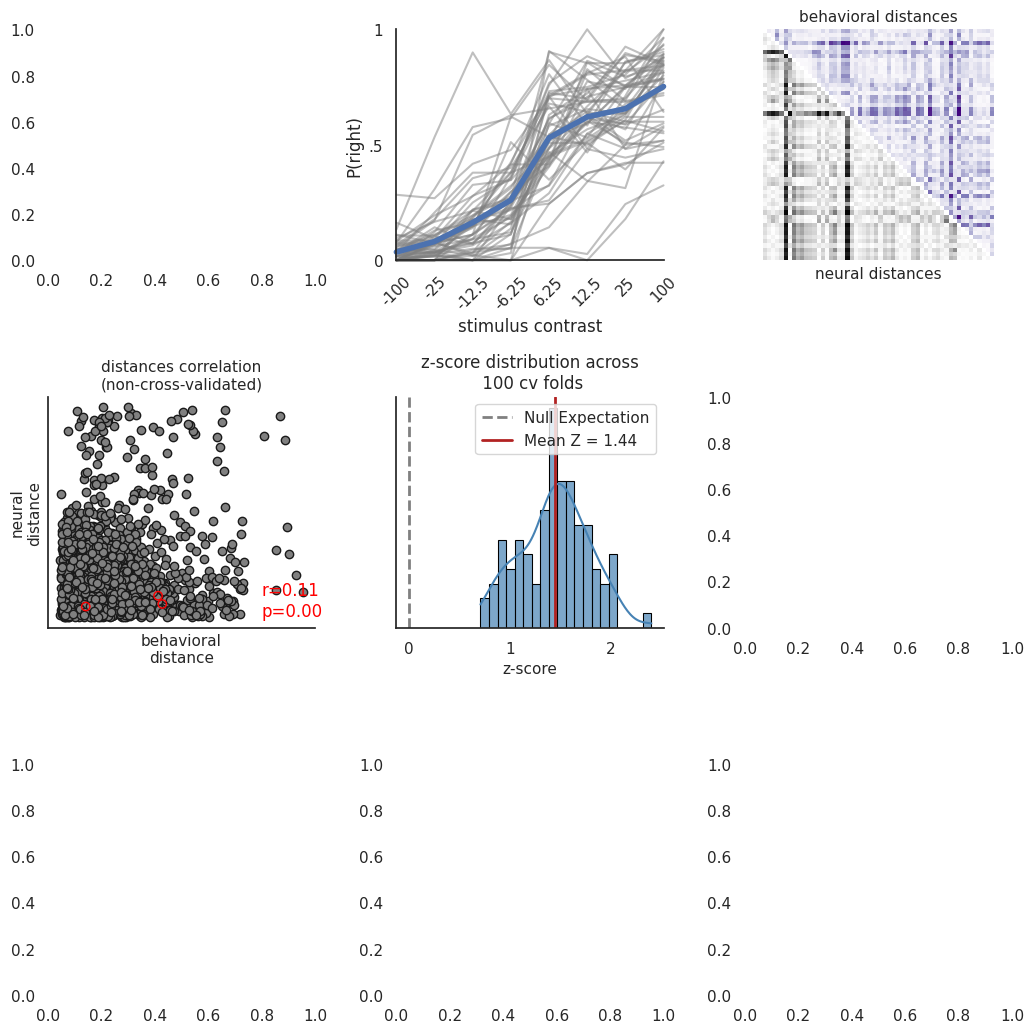

In [ ]:
# FIGURE 1-4
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,7*1.5), constrained_layout=True)
sns.despine(left=True, bottom=True)

# Adding to the figure 
examples_idx= [10,12,19]

axes = axes.flatten()

### First - PSYCHOMETRIC CURVES
contrast = [-100.  ,  -25.  ,  -12.5 ,   -6.25,    0.  ,    6.25,   12.5 ,
         25.  ,  100.  ]

avg_cc = [np.mean(c==1,0) for c in cs_trials]

choices = convert_to_rw_choices(cs_trials)
axes[1].plot(choices.T, color='gray', alpha=0.5,clip_on=False)
axes[1].plot(np.nanmean(choices,0), lw=4,clip_on=False)   
axes[1].set_ylabel("P(right)")
axes[1].set_xlabel("stimulus contrast")
axes[1].set_xticks(range(len(contrast)-1),[-100,-25,-12.5,-6.25,6.25,12.5,25,100],rotation=45)
axes[1].set_yticks([0,0.5,1],[0,'.5',1])
axes[1].set_ylim(0,1)
axes[1].set_xlim(0,7)
sns.despine(bottom=False, left=False, ax=axes[1])

colors = np.array(sns.color_palette(None, S))

### Second - DISTANCE MATRICES
dist_neural = np.asarray(dist_neural, dtype=float)
dist_cc = np.asarray(dist_cc, dtype=float)
dist_neural_ = dist_neural.copy()
dist_cc_ = dist_cc.copy()
dist_neural_[np.triu_indices(dist_neural.shape[0], 0)] = np.nan
dist_cc_[np.tril_indices(dist_neural.shape[0], 0)] = np.nan

axes[2].imshow(dist_neural_,cmap="Grays")

axes[2].set_xlabel("neural distances", fontsize=11)

axes[2].set_title('behavioral distances', fontsize=11)
axes[2].imshow(dist_cc_,cmap="Purples")
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,left=False,labelleft=False,right=True,labelright=True)

#change ticks fontsize
for ti,tick in enumerate(axes[2].get_xticklabels()):
    tick.set_fontsize(8)
    axes[2].get_yticklabels()[ti].set_fontsize(8)
    #axes[1].get_xticklabels()[ti].set_fontsize(8)
    #axes[1].get_yticklabels()[ti].set_fontsize(8)


### Third - SCATTER PLOT OF DISTANCES
# take upper triangle for the non-cross-validated data
flat_dist_neural = dist_neural_nocv[jnp.triu_indices(S,1)]
flat_dist_cc = dist_cc_nocv[jnp.triu_indices(S,1)]

axes[3].scatter( flat_dist_cc,flat_dist_neural,color="k",facecolors='gray')
axes[3].text(1.5,0.1,"r={:.2f}\np={:.2f}".format(r_dist,p_dist),color="red")
axes[3].set_xlabel("behavioral\ndistance", fontsize=11)
axes[3].set_ylabel("neural\ndistance", fontsize=11)
axes[3].set_xticks([])
axes[3].set_yticks([])
axes[3].set_title("distances correlation\n(non-cross-validated)", fontsize=11)
axes[3].scatter(dist_cc[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),
                dist_neural[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),facecolors='none', edgecolors='red',zorder=10)
sns.despine(bottom=False, left=False, ax=axes[3])

### Fourth - DISTRIBUTION OF Z SCORES
from scipy.stats import norm
r = np.array(all_c_corrs[:, 0])
null_means = np.array([np.mean(c) for c in all_c_corrs[:, 1]])
null_stds = np.array([np.std(c) for c in all_c_corrs[:, 1]])

# Calculate Z-scores
z = (r - null_means) / null_stds

print(f'Mean {z.mean()}, cdf {norm.cdf(z.mean())}')

sns.histplot(
    z, 
    bins=20, 
    kde=True, 
    color="steelblue", 
    edgecolor="black", 
    alpha=0.7,
    ax=axes[4]
) 

#sns.kdeplot(null_means, color='orange', linewidth=2, alpha=0.7, ax=ax)

axes[4].axvline(0, color='gray', linestyle='--', linewidth=2, label='Null Expectation')
axes[4].axvline(np.mean(z), color='firebrick', linestyle='-', linewidth=2, label=f'Mean Z = {np.mean(z):.2f}')

axes[4].set_yticks([])
axes[4].set_yticklabels([])
axes[4].set_ylabel('')
axes[4].set_xlabel('z-score', fontsize=11)
axes[4].set_title('z-score distribution across\n 100 cv folds', fontsize=12)
axes[4].legend(frameon=True, facecolor='white')
sns.despine(bottom=False, left=False, ax=axes[4])

'''
### Fourth - DISTRIBUTION OF CORRELATIONS ACROSS FOLDS

axes[4].set_title("distances correlation\nacross folds")
data_corrs = np.array(all_c_corrs, dtype=object)[:,0]
low, high = np.percentile(data_corrs,[2.5,97.5])

#shuffle_corrs = np.array(all_c_corrs, dtype=object)[:,1].mean()
shuffle_corrs = np.concatenate([np.asarray(c) for c in all_c_corrs[:, 1]])
shuffle_corrs = np.array([np.asarray(c).mean() for c in all_c_corrs[:, 1]])
sns.violinplot(data_corrs,label="data",ax=axes[4])
sns.violinplot(shuffle_corrs,label="shuffle",ax=axes[4],clip_on=False, alpha=0.5)
axes[4].legend()
axes[4].set_ylabel("pearsonr\ncorrelation")
#axes[4].text(0.1,0.02,"low={:.2f}\n high={:.3f}".format(low,high),color='r')  
axes[4].set_yticks([0,0.25])
axes[4].set_ylim(-0.25,0.25)
axes[4].set_xticks([])
'''

plt.tight_layout()
plt.savefig('IBL_distances.svg',dpi=300)
plt.show()


### FIGURE 5 is the per-region correlation distibution plot

In [ ]:
import pandas as pd

# Relaxing also the number of folds and shuffles
n_folds = 50

all_regions_c_corrs = []
all_regions_z = []
all_regions_p = {}

## Iterate over regions
regions = ['VISa','CA1', 'DG', 'LP', 'PO'] #, 'MRN',

DATA_DIR = Path.cwd() / "ibl_analyses" / "notebooks" / "prep_data"

for region in regions:

    # For each fold, save the correlation between neural and behavioral distance, 
    # and the correlation between each subject's behavior and the average of its top K neighbors in neural space
    region_c_corr = []
    region_z = []
    with open(DATA_DIR / f"100_folds_1_time_point_{region}.pkl","rb") as f:
        [params,train_data_folds,test_data_folds] = pickle.load(f)

    all_dist_neural = []
    all_dist_cc = []
    corr_shuffles = []
    # Iterate over folds
    for fold in tqdm.trange(n_folds):

        train_fold, test_fold = train_data_folds[fold], test_data_folds[fold]

        try: 
            # Compute distance matrices on each fold
            dist_neural_r,dist_cc_r,cs_r = get_dists(train_fold,test_fold,n_trials_total=None,metric='area')
        except np.linalg.LinAlgError:
            print("linalg error")
            region_c_corr.append(np.nan)
            region_z.append(np.nan)

            continue
        
        # No need to save for this analysis
        all_dist_neural.append(dist_neural_r)
        all_dist_cc.append(dist_cc_r)
        
        S = dist_neural_r.shape[0]
        mask = np.triu_indices(S,1)
        flat_dist_neural = dist_neural_r[mask]
        flat_dist_cc = dist_cc_r[mask]

        r,_ = sts.pearsonr(flat_dist_cc,flat_dist_neural)
        region_c_corr.append(r)

        # Compute null 
        shuffle_corrs = distances_mantel(dist_neural_r, dist_cc_r, n_perm=1000, seed=58)
        z = (r - np.mean(shuffle_corrs)) / np.std(shuffle_corrs)
        region_z.append(z)
        corr_shuffles.append(shuffle_corrs)

    # Save results for this region
    all_regions_c_corrs.append(np.array(region_c_corr))
    all_regions_z.append(np.array(region_z))

    # TESTING SIGNIFICANCE - CONFUSING: WHAT IS THE BEST APPROACH?
    # p values are ~U(0,1) so they cannot be averaged across folds to get an estimation
    # Perform Mantel test on the mean distance matrices across folds
    mean_dist_neural = np.nanmean(all_dist_neural, axis=0)
    mean_dist_cc = np.nanmean(all_dist_cc, axis=0)
    shuffle_corrs = distances_mantel(mean_dist_neural, mean_dist_cc, n_perm=1000)
    flat_dist_neural = mean_dist_neural[mask]
    flat_dist_cc = mean_dist_cc[mask]
    r,_ = sts.pearsonr(flat_dist_cc,flat_dist_neural)
    p = (np.sum(np.array(shuffle_corrs) >= r) + 1) / (len(shuffle_corrs) + 1)
    print(r, p)

    # Another way of doing it as claude suggested - take the mean axis=0 across all folds and use this as null
    r = np.nanmean(region_c_corr)
    null_d = np.mean(np.array(corr_shuffles), axis=0)
    p_c = (np.sum(null_d >= r) + 1) / (len(null_d) + 1)
    print(r, p_c)

    all_regions_p[region] = np.array([p, p_c])

lengths = [n_folds]*len(regions) 
region_info = pd.DataFrame({
    "region": np.repeat(regions, lengths),
    "corr": np.concatenate(all_regions_c_corrs),
    "z-score": np.concatenate(all_regions_z)
})

100%|██████████| 50/50 [00:38<00:00,  1.29it/s]


0.12138875515786503 0.16983016983016982
0.10889589875455119 0.14585414585414586


 42%|████▏     | 21/50 [00:40<00:52,  1.81s/it]

linalg error


100%|██████████| 50/50 [01:35<00:00,  1.91s/it]


...

0.17900010526114937 0.025974025974025976
0.15777067458345448 0.028971028971028972


100%|██████████| 50/50 [00:48<00:00,  1.02it/s]


0.042015368311538064 0.3516483516483517
0.037110982585362155 0.3516483516483517


100%|██████████| 50/50 [01:27<00:00,  1.76s/it]


0.24593083631540613 0.07192807192807193
0.2266781310417676 0.07892107892107893


In [17]:
all_regions_p_df = pd.DataFrame.from_dict(all_regions_p, orient='index', columns=['p_mantel', 'p_mean_null'])
all_regions_p_df

,p_mantel,p_mean_null
VISa,0.169830,0.145854
CA1,0.093906,0.086913
DG,0.025974,0.028971
LP,0.351648,0.351648
PO,0.071928,0.078921


In [16]:
region_info.groupby('region').agg({'corr': ['mean', 'std'], 'z-score': ['mean', 'std']})


corr             z-score          
            mean       std      mean       std
region                                        
CA1     0.105095  0.048603  1.275525  0.589532
DG      0.157771  0.050640  1.850544  0.572527
LP      0.037111  0.036819  0.321853  0.358439
PO      0.226678  0.049719  1.570658  0.330192
VISa    0.108896  0.039776  1.002646  0.359213

<Axes: xlabel='z-score', ylabel='Count'>

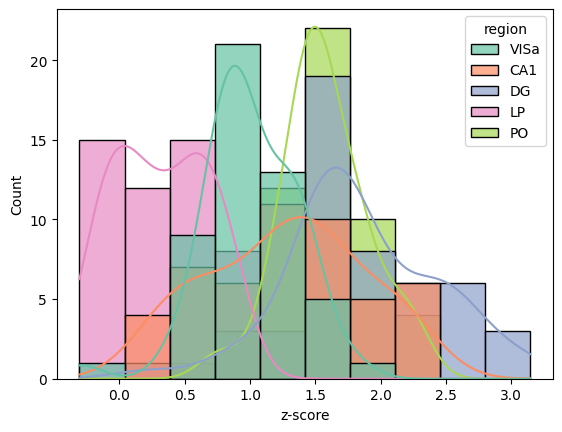

In [15]:
region_info
sns.histplot(
    data=region_info, 
    x="z-score", 
    hue="region", 
    bins=10, 
    kde=True, 
    palette=sns.color_palette("Set2", len(regions)),
    edgecolor="black", 
    alpha=0.7
)

/tmp/ipykernel_1249140/3358229775.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="region", y="corr", data=region_info, order=regions, palette=palette, ax=axes[5], inner='quartile', linewidth=1)
/tmp/ipykernel_1249140/3358229775.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


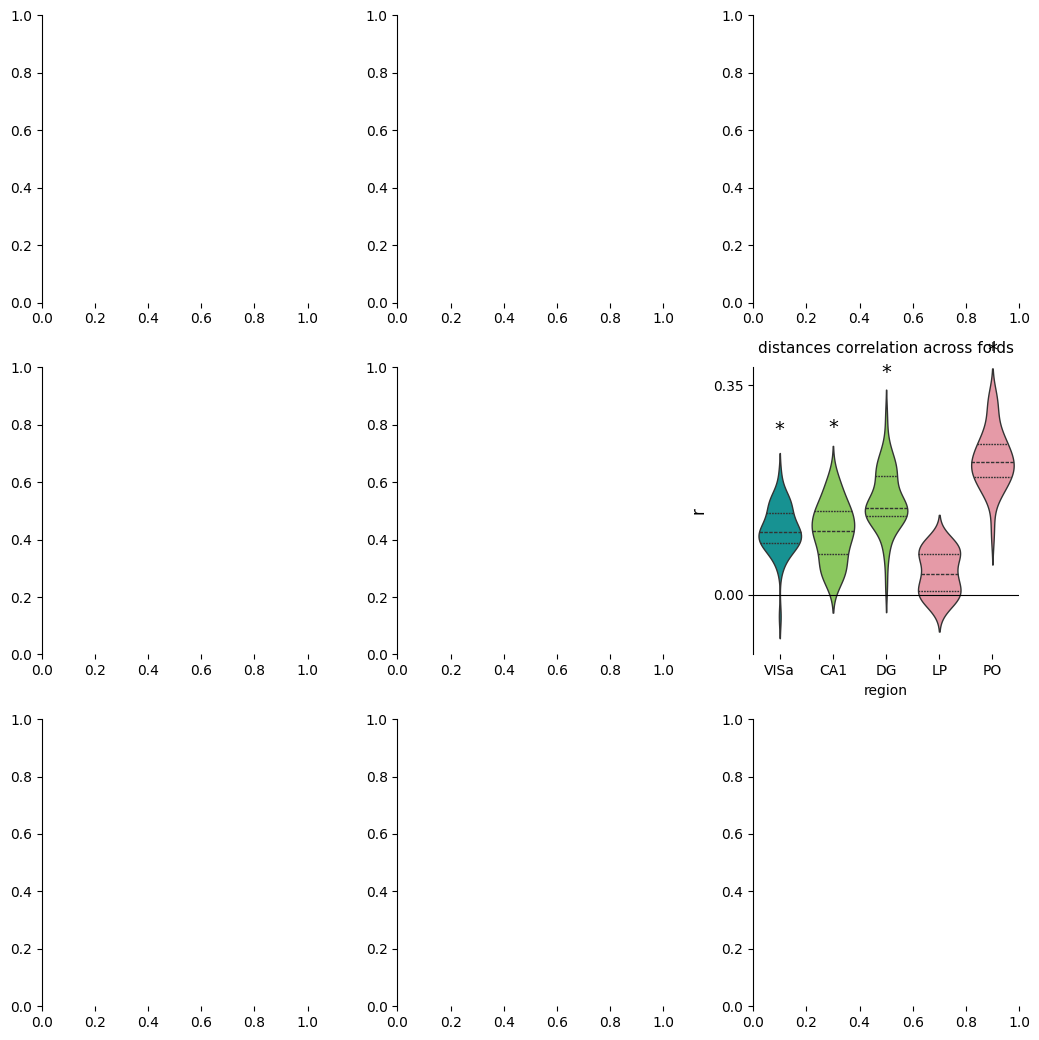

In [18]:
# FIGURE 5 
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,7*1.5), constrained_layout=True)

axes = axes.flatten()

colors = [ '#03A6A6', '#88D94E', '#88D94E', '#F28D9F', '#F28D9F', '#FF90FF']
#colors = ['#03A6A6', '#03A6A6', '#03A6A6', '#FF90FF', '#F28D9F']

palette = dict(zip(regions, colors))

# Plot distribution of correlations for each region
axes[5].set_title("distances correlation across folds", fontsize=11, pad=10)

# Use palette only (remove explicit 'color' to let palette apply correctly)
sns.violinplot(x="region", y="corr", data=region_info, order=regions, palette=palette, ax=axes[5], inner='quartile', linewidth=1)
axes[5].axhline(0, color='k', linewidth=.8)
axes[5].set_ylabel("r", fontsize=12)
axes[5].set_yticks([0, 0.35])
axes[5].set_ylim(-0.1, 0.38)

# Add significance stars where the lower 2.5% percentile of the distribution > 0
for i, region in enumerate(regions):
    vals = region_info.loc[region_info['region'] == region, 'corr'].values
    if len(vals) == 0:
        continue
    lower = np.nanpercentile(vals, 2.5)

    if lower > 0:
        # compute a y position just above the data for this region
        ylim = axes[5].get_ylim()
        data_max = np.nanmax(vals)
        margin = 0.02 * (ylim[1] - ylim[0])
        y = data_max + margin
        # expand ylim if needed to make the star visible
        if y > ylim[1] - margin:
            axes[5].set_ylim(ylim[0], y + margin)
        axes[5].text(i, y+0.05, '*', ha='center', va='bottom', fontsize=14, color='k')

plt.tight_layout()
sns.despine(bottom=True)

### Now, the last 3 figures are from ASD analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from scipy.cluster import hierarchy
from collections import defaultdict
from matplotlib.lines import Line2D
from scipy.stats import ttest_rel

%load_ext autoreload
%autoreload 2
import imp
import sys
sys.path.insert(1, "./ibl_autism/")
from scripts.utils import load_animal_kernels, list_regions, list_animals, filter_kernels_outliers, filter_distributions_outliers
from matplotlib.colors import Normalize
from scripts.metric import dsd

/tmp/ipykernel_1230701/3938255374.py:14: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [ ]:
# Load all unit kernels for each animal and region - separating across genotypes
# Plot average kernel per genotype across all regions 

genotypes = ['N', 'F', 'C', 'S']
contrast_names =    ['cL100', 'cL025', 'cL012', 'cL006', 'c0', 'cR006', 'cR012', 'cR025', 'cR100']
#colors = {'C':'blue', 'F':'red', 'N':'green', 'S':'orange'}
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

# For each genotype, for each region, get kernel and average across all neurons
genotype_kernels_neurons = defaultdict(list)
all_animals = []
n_neurons = []
for g in genotypes:
    animals_g = list_animals(g)
    regions = list_regions(g)

    all_animals.extend(animals_g)
    for animal in animals_g:

        animal_kernel = load_animal_kernels(g, regions, animal) # (n_units, n_contrasts, n_time_bins)
        # Filter for extreme outliers
        animal_kernel_filter = filter_kernels_outliers(animal_kernel, 97.5, 2.5)

        # If after filtering there are no more kernels left, skip this animal
        if len(animal_kernel_filter) > 0:
            genotype_kernels_neurons[g].append(animal_kernel_filter) # (subjects, n_units, contrasts, timepoints)
            n_neurons.append(animal_kernel_filter.shape[0])


In [ ]:
# Load and organize the kernels in one array
# What can i do now? I can maybe try to cluster the kernels across genotypes
# Maybe I can, instead of using all neurons, selecting just the areas in common?

all_subjects = []
all_genotypes=[]
for g in genotypes:
    print(g)
    arrs = genotype_kernels_neurons[g]
    # Keeping the most relevant conditions to reduce dimensionality (from 9*106 to 3*106)
    arrs = [a[:,3:6,:] for a in arrs] 
    if len(arrs) == 0:
        continue
        
    # Just filter out the subjects with less than 100 neurons, but keep all neurons
    vals = [a.reshape(a.shape[0], -1).T for a in arrs if len(a) >= 100] # (n_neurons, contrast*timepoints) for each subject

    # filtering
    vals = filter_distributions_outliers(vals, percentile_upper=97.5)
    all_genotypes.extend([g]*len(vals))

    # Now vals has the shape (subjects, timepoints * conditions, neurons)
    all_subjects.extend(vals)

# Compute distances
labels_arr = np.array(all_genotypes)

S = len(all_subjects)
dist_neural = dsd([
    [all_subjects[i], all_subjects[j]]
    for i in range(S) 
    for j in range(S)]
    ).reshape(S,S)


N
F
C
S


2026-07-31 10:39:55,931	INFO worker.py:2013 -- Started a local Ray instance.
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [ ]:
# FOR THE STATISTICAL TEST OF DIFFERENCES: get the neural distances and compute:
# 1. distance matrix within control (mean for each control subject to each other control subject)
# 2. distance matrix between each control and each other genotype (so, each control and the average distance between subjects of a genotype)
# 3. now you have #ControlSubjects references and 4 variations 

def within_distance(dist_matrix, labels, genotype):
    mask_g = labels == genotype
    within = dist_matrix[np.ix_(mask_g, mask_g)]
    np.fill_diagonal(within, np.nan) 
    return within

def across_distance(dist_matrix, labels, g1, g2):
    mask_g1 = labels == g1
    mask_g2 = labels == g2
    return dist_matrix[np.ix_(mask_g1, mask_g2)]

# Get mean distances for each control (first dimension) subject
control = np.nanmean(within_distance(dist_neural, labels_arr, 'N'), axis=1)
control_vs_F = across_distance(dist_neural, labels_arr, 'N', 'F').mean(axis=1)
control_vs_C = across_distance(dist_neural, labels_arr, 'N', 'C').mean(axis=1)
control_vs_S = across_distance(dist_neural, labels_arr, 'N', 'S').mean(axis=1)

# create a dataframe for plotting
df_control_distances = pd.DataFrame({
    'control_subject': np.arange(len(control)),
    'Within control': control,
    'Control vs S': control_vs_S,
    'Control vs F': control_vs_F,
    'Control vs C': control_vs_C,
})


In [ ]:

def plot_dendogram(dist_neural, labs, fig=None, save=False, lab_to_color=None, title=False):
    
    S = dist_neural.shape[0]
    
    dist_neural_flat = dist_neural[np.triu_indices(S,1)] #squareform(dist_neural)

    linkage = hierarchy.ward(dist_neural_flat)
    linkage = hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    if fig is None:
        fig = plt.figure(figsize=(4,5))
    # Plot all together in the same figure...
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.02)

    ax_dendro = fig.add_subplot(gs[0])
    ax_heatmap = fig.add_subplot(gs[1])

    dn = hierarchy.dendrogram(
        linkage, 
        ax=ax_dendro, 
        color_threshold=0, 
        above_threshold_color='k'
    )
    ax_dendro.axis('off')

    leaf_order = hierarchy.leaves_list(
        hierarchy.optimal_leaf_ordering(linkage, dist_neural_flat)
    )
    if lab_to_color is None:
        unique_labs = np.unique(labs)
        cmap = plt.get_cmap('tab10') 
        lab_to_color = {lab: cmap(i / len(unique_labs)) for i, lab in enumerate(unique_labs)}

    x_coords = np.arange(5, S * 10 + 5, 10)

    for i, original_idx in enumerate(leaf_order):
        lab = labs[original_idx]
        color = lab_to_color[lab]
        ax_dendro.scatter(x_coords[i], 0, color=color, s=60, zorder=10, clip_on=False)

    ordered_dist = dist_neural[leaf_order, :][:, leaf_order]
    
    ax_heatmap.imshow(ordered_dist, cmap="gray", aspect='auto', 
                      vmin=np.min(ordered_dist), vmax=np.max(ordered_dist))

    ax_heatmap.set_xticks([])
    ax_heatmap.set_yticks([])

    if title:
        plt.title('Distance matrix with dendrogram ordering', fontsize=12, y=1.2)
    
    for spine in ax_heatmap.spines.values():
        spine.set_visible(False)

    if save:
        plt.savefig(f"distance_dendrogram.png", dpi=300, bbox_inches='tight')
    
    return fig, ax_dendro, ax_heatmap


In [ ]:
def plot_mds_pca(dist_matrix, labels, n_components=50, ax=None):

    # DIstance matrices are not euclidean so PCA directly is not ideal
    # MDS on the distance matrix
    mds = MDS(n_components=n_components, 
              dissimilarity='precomputed', 
              random_state=66,
              normalized_stress=False,
              n_init=10,)
    
    mds_coords = mds.fit_transform(dist_matrix)

    #mds_coords = (mds_coords - mds_coords.mean(axis=0)) / mds_coords.std(axis=0)

    # PCA on MDS coordinates
    pca_2d = PCA(n_components=2, random_state=42)
    pca_coords = pca_2d.fit_transform(mds_coords)

    colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}
    map_labels = {'C':'Cntnap2', 'F':'Fmr1', 'N':'C57BL6', 'S':'Shank3'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    # PCA on MDS plot
    for g in np.unique(labels):
        mask = np.array(labels) == g
        ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                        c=colors[g], label=map_labels[g], s=60, edgecolors='white', linewidths=0.5)

    ax.set_xticks([])
    ax.set_xticklabels([])

    ax.set_yticks([])
    ax.set_yticklabels([])

    ax.legend()

    sns.despine(ax=ax)

    return ax, pca_coords

In [ ]:
def genotype_perm_test(D, labels, g1, g2, n_perm=10000, seed=0):
    """Is the g1-g2 distance larger than the within-g1 distance?
    Null: shuffle the genotype label attached to each subject."""
    rng = np.random.default_rng(seed)
    def stat(lab):
        w = D[np.ix_(lab == g1, lab == g1)].astype(float)
        np.fill_diagonal(w, np.nan)
        return np.nanmean(D[np.ix_(lab == g1, lab == g2)]) - np.nanmean(w)
    obs = stat(labels)
    null = np.array([stat(rng.permutation(labels)) for _ in range(n_perm)])
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1)

def control_perm_test(D, labels, g1, g2, n_perm=10000, seed=0):
    """Is the control-g2 distance larger than the control-g1 distance?
    Just like the test above, but instead of comparing the mean of clusters, 
    compare the mean distance of each control and the mean for other genotype
    for different permutations
    Null: shuffle the genotype label attached to each subject."""
    rng = np.random.default_rng(seed)
    def stat(lab):
        w = within_distance(D, lab, g1)
        across = across_distance(D, lab, g1, g2)
        diff_control = np.nanmean(across, axis=1) - np.nanmean(w, axis=1) # mean for each control subjects
        return diff_control.mean()  # mean across all control subjects
    obs = stat(labels) 
    null = np.array([stat(rng.permutation(labels)) for _ in range(n_perm)])
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1)

-1.594587011290815 0.14947075279570324
0.1563843615638436
-2.4466125456004844 0.04014828062978102
0.06979302069793021
-4.501411611919427 0.001998359765869544
0.0160983901609839


/tmp/ipykernel_1230701/316761464.py:105: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[8].legend(frameon=False, loc='upper left', fontsize=10)
/tmp/ipykernel_1230701/316761464.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1230701/316761464.py:107: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


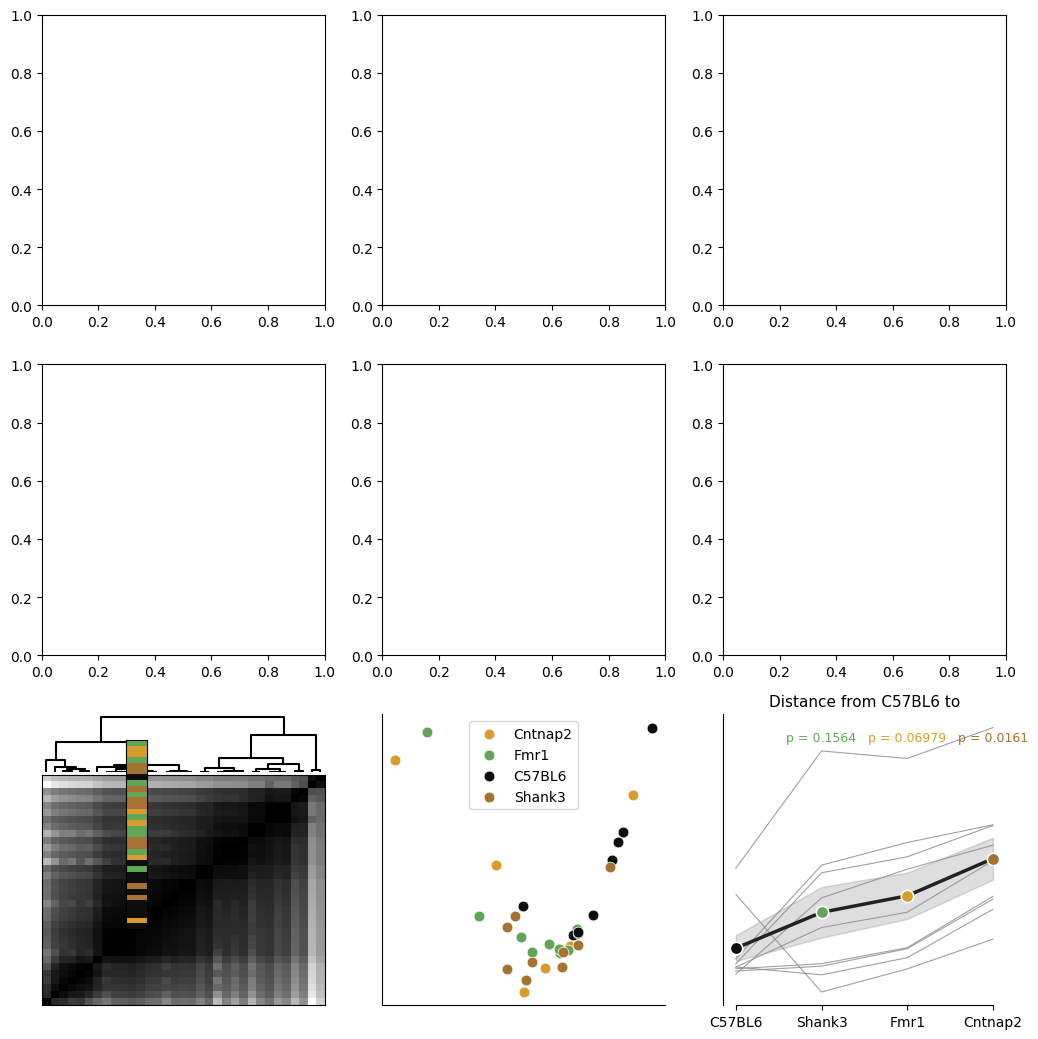

In [ ]:
## Figure 6-8

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(7*1.5,7*1.5), constrained_layout=True)
axes = axes.flatten()

# FIG 6 - HIERARCHICAL CLUSTERING AND ORDERING (drawn inside axes[6])
colors = {'N':'#0D0D0D', 'F':'#61A656', 'C':'#D99C2B', 'S':'#A67232'}

# FIG 7 - PCA (placed in axes[7])
ax_pca, _ = plot_mds_pca(dist_neural, labels_arr, ax=axes[7])

# FIG 6 - ORDERED DISTANCE MATRIX + DENDROGRAM (place inside axes[6])
from scipy.cluster import hierarchy
import matplotlib.colors as mcolors
from matplotlib import gridspec

S = dist_neural.shape[0]
condensed = dist_neural[np.triu_indices(S,1)]
linkage = hierarchy.ward(condensed)
linkage = hierarchy.optimal_leaf_ordering(linkage, condensed)
leaf_order = hierarchy.leaves_list(linkage)
ordered_dist = dist_neural[leaf_order, :][:, leaf_order]

# Replace axes[6] with two stacked subaxes (dendrogram above heatmap)
axes[6].clear()
axes[6].set_xticks([])
axes[6].set_yticks([])
sns.despine(ax=axes[6], left=True, bottom=True)
gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=axes[6].get_subplotspec(), height_ratios=[1, 4], hspace=0.02)
dendro_ax = fig.add_subplot(gs_inner[0])
heatmap_ax = fig.add_subplot(gs_inner[1])

# Dendrogram (top)
dn = hierarchy.dendrogram(linkage, ax=dendro_ax, no_labels=True, color_threshold=0, above_threshold_color='k')
dendro_ax.axis('off')

# Heatmap (bottom)
heatmap_ax.imshow(ordered_dist, cmap='gray', aspect='auto', vmin=np.nanmin(ordered_dist), vmax=np.nanmax(ordered_dist), origin='lower')
heatmap_ax.set_xticks([])
heatmap_ax.set_yticks([])
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

# Small genotype color strip aligned with rows of the heatmap
ordered_labels = labels_arr[leaf_order]
lab_to_color = colors
color_list = mcolors.to_rgba_array([lab_to_color[lab] for lab in ordered_labels])
pos2 = heatmap_ax.get_position()
strip_width = 0.02
pad = 0.005
new_heatmap_left = pos2.x0 + strip_width + pad
new_heatmap_width = max(pos2.width - (strip_width + pad), pos2.width * 0.5)
heatmap_ax.set_position([new_heatmap_left, pos2.y0, new_heatmap_width, pos2.height])
cax = fig.add_axes([pos2.x0, pos2.y0, strip_width, pos2.height])
cax.imshow(color_list.reshape(-1,1,4), aspect='auto', origin='lower')
cax.set_xticks([])
cax.set_yticks([])

## FIG 8 - PARALLEL T-TEST PLOT (axes[8])
cols = ['Within control', 'Control vs S', 'Control vs F', 'Control vs C']
x_labels = ['C57BL6', 'Shank3', 'Fmr1', 'Cntnap2']

for _, row in df_control_distances[cols].iterrows():
    axes[8].plot(range(len(cols)), row.values, color='#888888', alpha=0.8, linewidth=0.8, zorder=3)

means = df_control_distances[cols].mean(axis=0)
sem = df_control_distances[cols].sem(axis=0)

axes[8].fill_between(range(len(cols)), means - sem, means + sem,
                color='#222222', alpha=0.15, zorder=2)

mean_colors = ['#0D0D0D', '#61A656', '#D99C2B', '#A67232']
axes[8].plot(range(len(cols)), means.values, color='#222222', linewidth=2.5, zorder=3)

for xi, col in enumerate(cols):
    axes[8].scatter(xi, means[col], color=mean_colors[xi], s=80, zorder=4, edgecolor='white', linewidth=1.2)

results = {}
a = df_control_distances['Within control'].values
y_max_val = df_control_distances[cols].max().max()

for xi, col in enumerate(['Control vs S', 'Control vs F', 'Control vs C'], start=1):
    b = df_control_distances[col].values
    mask = (~np.isnan(a)) & (~np.isnan(b))
    if mask.sum() >= 2:
        t_stat, p_val = ttest_rel(a[mask], b[mask])
        print(t_stat, p_val)
        obs, p_val = genotype_perm_test(dist_neural, labels_arr, 'N', col.split()[-1])  
        print(p_val)

        results[col] = {'n': int(mask.sum()), 't': float(t_stat), 'p': float(p_val)}

        axes[8].text(xi, y_max_val - (0.05 * y_max_val), f'p = {p_val:.4g}', ha='center', va='bottom', fontsize=9, color=mean_colors[xi])

axes[8].set_xticks(range(len(cols)))
axes[8].set_xticklabels(x_labels, fontsize=10)
axes[8].set_yticks([])

axes[8].set_title('Distance from C57BL6 to', fontsize=11)

sns.despine(ax=axes[8], trim=True)
axes[8].grid(axis='y', color="#ECE9E9", linewidth=0.8, linestyle='--')
axes[8].grid(axis='x', visible=False)
axes[8].legend(frameon=False, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Time resolved correlation

In [ ]:

import jax.numpy as jnp
import sys
sys.path.insert(1,'./ibl_analysis/scripts/')
import utils

import matplotlib as mpl
import matplotlib.pyplot as plt

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

In [ ]:
# Taken from script 'time_resolved_corr.py'
# Takes a long time to process...
from utils import plot_time_corrs, load_and_process_fold
w, s = 10, 2
region = 'all'

# Load and process the data for response
all_corrs_resp = load_and_process_fold(region, 'response', w, s)
print("Done loading and processing response")
# same with stimulus
all_corrs_stim = load_and_process_fold(region, 'stim', w, s)
print("Done loading and processing stimulus")

# plotting the results
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))
all_corrs = {'response': all_corrs_resp, 'stim': all_corrs_stim}
ax = plot_time_corrs(all_corrs, ax=ax, w=w, s=s)
plt.show()

ImportError: cannot import name 'plot_time_corrs' from 'utils' (/home/blopes/ShapeMetrics/./ibl_autism/scripts/utils.py)